In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu
import prep_moth_data as pmd
from collections import defaultdict, Counter

USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""

In [161]:
# ## Old:
# df_moth_data = pu.prep_moth_data_for_regression(location_list=['HV', 'OH'], 
#                         dir_moth_data= '/Users/tplas/data/2025-06-16 moth data Natalie/')
## New:
df_moth_data = pu.prep_moth_data_for_regression(location_list=['HV', 'OH'], 
                        dir_moth_data= '/Users/tplas/data/2025-10-07 moth raw data 2023/',
                        file_name='Qry_D50_AllClutches_CommonGarden.csv')
df_bb_data = pu.prep_budburst_data_for_regression(species_sel='Quercus robur L.', location_list=['Hoge Veluwe'])

/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


THere are 7397 rows in the moth data from /Users/tplas/data/2025-10-07 moth raw data 2023/Qry_D50_AllClutches_CommonGarden.csv
No temperature data for year 2024 - removing MOTH data for this year.
No temperature data for year 2025 - removing MOTH data for this year.
No dataframes provided -- using default budburst and temperature data


/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


Filtering data for locations: ['Hoge Veluwe']


In [162]:
def get_area_between_cdfs(df_moth, df_bb):
    df_moth = df_moth[['moth_cdf', 'date', 'season']]
    df_bb = df_bb[['bb_cdf', 'date', 'season']]

    df_merged = pd.merge(df_moth, df_bb, on='date', how='inner')  ## inner join to ensure same date range
    assert df_merged['season_x'].equals(df_merged['season_y']), "Seasons do not match after merge"
    df_merged = df_merged.rename(columns={'season_x': 'season'})
    df_merged = df_merged.drop(columns=['season_y'])
    df_merged['cdf_diff'] = np.abs(df_merged['moth_cdf'] - df_merged['bb_cdf'])
    area_between = df_merged.groupby('season')['cdf_diff'].sum().to_dict()
    df_area = pd.DataFrame(area_between.items(), columns=['season', 'area_between_cdfs'])
    df_area['year'] = df_area['season'].apply(lambda x: int(x.split('-')[1]))
    return df_area, df_merged

df_area_between_cdfs, _ = get_area_between_cdfs(df_moth_data, df_bb_data)
df_area_between_cdfs


,season,area_between_cdfs,year
0,1994-1995,16.839869,1995
1,1995-1996,15.752895,1996
2,1996-1997,27.082418,1997
3,1997-1998,26.415789,1998
4,1998-1999,19.658826,1999
5,1999-2000,16.932281,2000
6,2000-2001,20.036667,2001
7,2001-2002,25.965449,2002
8,2002-2003,13.932903,2003
9,2003-2004,16.008979,2004


In [163]:
def get_percentiles(df_data, col_cdf='bb_cdf', col_aprilday='AprilDay', fractions=[0.05, 0.25, 0.5, 0.75, 0.95], percentiles=[10, 25, 50, 75, 90]):
    '''Fit CDF with sigmoid, get percentiles.'''
    assert col_cdf in df_data 
    assert col_aprilday in df_data 

    x, y = df_data[col_aprilday], df_data[col_cdf]

    try:
        popt, pcov = curve_fit(pmd.sigmoid, x, y, 
                            p0=[0, 1], maxfev=10000)
        midpoint = popt[0]
        steepness = popt[1]
    except RuntimeError as e:
        print(f"Could not fit sigmoid: {e}")

    dict_fits = {p: pmd.inv_sigmoid(y=p, x0=midpoint, k=steepness) for p in fractions}
    return dict_fits, (midpoint, steepness)


dict_percentiles_bb = {k: [] for k in ['year', 5, 25, 50, 75, 95]}

years_use = [int(x.split('-')[1]) for x in df_bb_data.season.unique().tolist()]
for year in sorted(years_use):
    df_tmp = df_bb_data[df_bb_data.date.dt.year == int(year)]
    df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
    dict_fits, (midpoint, steepness) = get_percentiles(df_tmp, col_cdf='bb_cdf', col_aprilday='april_day')
    dict_percentiles_bb['year'].append(year)
    dict_percentiles_bb[5].append(dict_fits[0.05])
    dict_percentiles_bb[25].append(dict_fits[0.25])
    dict_percentiles_bb[50].append(dict_fits[0.5])
    dict_percentiles_bb[75].append(dict_fits[0.75])
    dict_percentiles_bb[95].append(dict_fits[0.95])

dict_percentiles_moth = {k: [] for k in ['year', 5, 25, 50, 75, 95]}
years_use = [int(x.split('-')[1]) for x in df_moth_data.season.unique().tolist()]
for year in sorted(years_use):
    df_tmp = df_moth_data[df_moth_data.date.dt.year == int(year)]
    df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
    dict_fits, (midpoint, steepness) = get_percentiles(df_tmp, col_cdf='moth_cdf', col_aprilday='april_day')
    dict_percentiles_moth['year'].append(year)
    dict_percentiles_moth[5].append(dict_fits[0.05])
    dict_percentiles_moth[25].append(dict_fits[0.25])
    dict_percentiles_moth[50].append(dict_fits[0.5])
    dict_percentiles_moth[75].append(dict_fits[0.75])
    dict_percentiles_moth[95].append(dict_fits[0.95])

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_70284/3407985068.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_70284/3407985068.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_70284/3407985068.py:25: SettingWithCopyWarning: 
A value is try

In [164]:
# df_bb_data[df_bb_data.date.dt.month == 4].groupby(df_bb_data.date).drop(columns=['season', 'date'])
df_bb_data['month'] = df_bb_data.date.dt.month
df_bb_data['year'] = df_bb_data.date.dt.year
df_temp_data_jan = df_bb_data[df_bb_data.month.isin([1])][['temperature', 'year']].groupby('year').mean().reset_index()
df_temp_data_feb = df_bb_data[df_bb_data.month.isin([2])][['temperature', 'year']].groupby('year').mean().reset_index()
df_temp_data_march = df_bb_data[df_bb_data.month.isin([3])][['temperature', 'year']].groupby('year').mean().reset_index()
df_temp_data_april = df_bb_data[df_bb_data.month.isin([4])][['temperature', 'year']].groupby('year').mean().reset_index()
df_temp_data_marchapril = df_bb_data[df_bb_data.month.isin([3, 4])][['temperature', 'year']].groupby('year').mean().reset_index()
df_temp_data_diff_march_april = df_temp_data_april.copy()
df_temp_data_diff_march_april = df_temp_data_diff_march_april.rename(columns={'temperature': 'temp_april'})
df_temp_data_diff_march_april = df_temp_data_diff_march_april.merge(
    df_temp_data_march.rename(columns={'temperature': 'temp_march'}),
    on='year'
)
df_temp_data_diff_march_april['temp_diff_march_april'] = df_temp_data_diff_march_april['temp_april'] - df_temp_data_diff_march_april['temp_march']  
df_temp_data_diff_march_april.rename(columns={'temp_diff_march_april': 'temperature'}, inplace=True)
df_temp_data_diff_march_april = df_temp_data_diff_march_april[['year', 'temperature']]
# df_bb_data_april

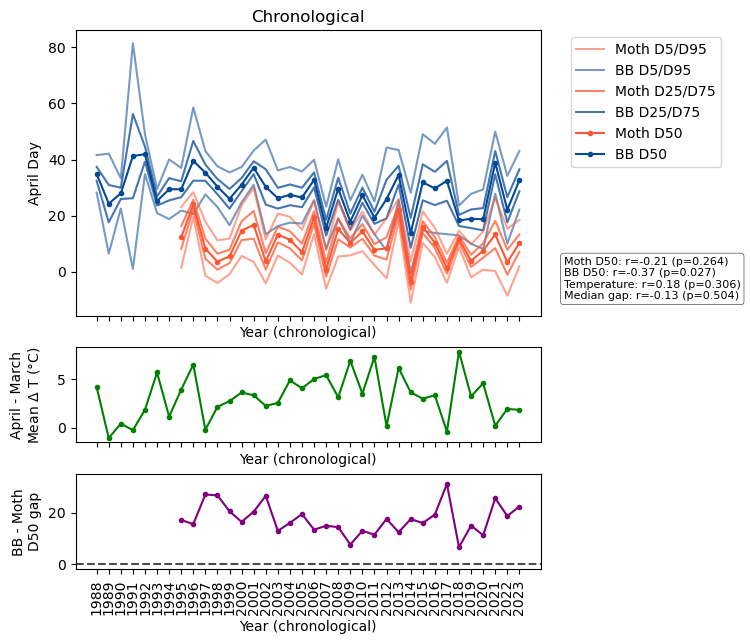

In [204]:
sort_mode = 'chronological'
temperature_mode = 'march_april_diff'

if temperature_mode == 'march':
    df_temp = df_temp_data_march
    ylabel_temp = 'March\nMean Temp (°C)'
elif temperature_mode == 'april':
    df_temp = df_temp_data_april
    ylabel_temp = 'April\nMean Temp (°C)'
elif temperature_mode == 'march_april':
    df_temp = df_temp_data_marchapril
    ylabel_temp = 'March + April\nMean Temp (°C)'
elif temperature_mode == 'jan':
    df_temp = df_temp_data_jan
    ylabel_temp = 'January\nMean Temp (°C)'
elif temperature_mode == 'feb':
    df_temp = df_temp_data_feb
    ylabel_temp = 'February\nMean Temp (°C)'
elif temperature_mode == 'march_april_diff':
    df_temp = df_temp_data_diff_march_april
    ylabel_temp = 'April - March\nMean ' + r"$\Delta$ " + 'T (°C)'
else:
    raise ValueError(f"Unknown temperature mode: {temperature_mode}")

if sort_mode == 'bb_d50':
    sorted_bb_inds = np.argsort(dict_percentiles_bb[50])
    sorted_bb_years = np.array(dict_percentiles_bb['year'])[sorted_bb_inds]
    sorted_moth_inds = [int(np.where(np.array(dict_percentiles_moth['year']) == yr)[0][0]) if yr in np.array(dict_percentiles_moth['year']) else None for yr in sorted_bb_years]
    arange_moth = np.where(np.array(sorted_moth_inds) != None)[0]
    sorted_moth_inds = np.array(sorted_moth_inds)[arange_moth].astype(int)
    sorted_moth_years = np.array(dict_percentiles_moth['year'])[sorted_moth_inds]
    xticks = np.arange(len(sorted_bb_years))
    xticklabels = sorted_bb_years
    xlabel = 'Year (sorted by BB median date)'
    plot_title = 'Sorted by BB D50'
elif sort_mode == 'moth_d50':
    sorted_moth_inds = np.argsort(dict_percentiles_moth[50])
    sorted_moth_years = np.array(dict_percentiles_moth['year'])[sorted_moth_inds]
    sorted_bb_inds = [np.where(np.array(dict_percentiles_bb['year']) == yr)[0][0] for yr in sorted_moth_years]
    sorted_bb_years = np.array(dict_percentiles_bb['year'])[sorted_bb_inds]
    arange_moth = np.arange(len(sorted_moth_years))
    xticks = arange_moth
    xticklabels = sorted_moth_years
    xlabel = 'Year (sorted by Moth median date)'
    plot_title = 'Sorted by Moth D50'
elif sort_mode == 'chronological':
    sorted_bb_inds = np.arange(len(dict_percentiles_bb['year']))
    sorted_bb_years = np.array(dict_percentiles_bb['year'])[sorted_bb_inds]
    sorted_moth_inds = [int(np.where(np.array(dict_percentiles_moth['year']) == yr)[0][0]) if yr in np.array(dict_percentiles_moth['year']) else None for yr in sorted_bb_years]
    arange_moth = np.where(np.array(sorted_moth_inds) != None)[0]
    sorted_moth_inds = np.array(sorted_moth_inds)[arange_moth].astype(int)
    sorted_moth_years = np.array(dict_percentiles_moth['year'])[sorted_moth_inds]
    xticks = np.arange(len(sorted_bb_years))
    xticklabels = sorted_bb_years
    xlabel = 'Year (chronological)'
    plot_title = 'Chronological'
elif sort_mode == 'temperature':
    sorted_bb_years = df_temp.sort_values(by='temperature')['year'].values
    sorted_bb_inds = [int(np.where(np.array(dict_percentiles_bb['year']) == yr)[0][0]) for yr in sorted_bb_years]
    sorted_moth_inds = [int(np.where(np.array(dict_percentiles_moth['year']) == yr)[0][0]) if yr in np.array(dict_percentiles_moth['year']) else None for yr in sorted_bb_years]
    arange_moth = np.where(np.array(sorted_moth_inds) != None)[0]
    sorted_moth_inds = np.array(sorted_moth_inds)[arange_moth].astype(int)
    sorted_moth_years = np.array(dict_percentiles_moth['year'])[sorted_moth_inds]
    xticks = np.arange(len(sorted_bb_years))
    xticklabels = sorted_bb_years
    xlabel = 'Year (sorted by temperature)'
    plot_title = f'Sorted by {ylabel_temp.replace("\n", " ")}'
elif sort_mode == 'area_between_cdfs':
    sorted_moth_years = df_area_between_cdfs.sort_values(by='area_between_cdfs')['year'].values
    sorted_moth_inds = [int(np.where(np.array(dict_percentiles_moth['year']) == yr)[0][0]) for yr in sorted_moth_years]
    sorted_bb_inds = [int(np.where(np.array(dict_percentiles_bb['year']) == yr)[0][0]) for yr in sorted_moth_years]
    sorted_bb_years = np.array(dict_percentiles_bb['year'])[sorted_bb_inds]
    arange_moth = np.arange(len(sorted_moth_years))
    xticks = np.arange(len(sorted_moth_years))
    xticklabels = sorted_moth_years
    xlabel = 'Year (sorted by area between CDFs)'
    plot_title = 'Sorted by Area Between CDFs'
else:
    raise ValueError(f"Unknown mode: {sort_mode}")


temp_data_sorted = df_temp.set_index('year').loc[xticklabels]['temperature'].values
fig, ax = plt.subplots(3, 1, figsize=(6, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
## plot percentiles over years sorted by moth median date
for perc in [5, 25, 50, 75, 95]:
    if perc == 50:
        legend_label = 'D50'
    elif perc < 50:
        legend_label = f'D{perc}/D{100 - perc}'
    else:
        legend_label = None
    sorted_perc_tmp_moth = np.array(dict_percentiles_moth[perc])[sorted_moth_inds]
    ax[0].plot(arange_moth, sorted_perc_tmp_moth, label=f'Moth {legend_label}' if perc < 51 else None, 
             color="#FF5733", alpha=1 - (abs(50 - perc) / 100), marker='.' if perc == 50 else None)
    sorted_perc_tmp_bb = np.array(dict_percentiles_bb[perc])[sorted_bb_inds]
    ax[0].plot(np.arange(len(sorted_perc_tmp_bb)), sorted_perc_tmp_bb, label=f'BB {legend_label}' if perc < 51 else None, 
             color="#054895", alpha=1 - (abs(50 - perc) / 100), marker='.' if perc == 50 else None)
    if perc == 50:
        median_gap = np.array(sorted_perc_tmp_bb)[arange_moth] - np.array(sorted_perc_tmp_moth)
        ax[2].plot(arange_moth, median_gap, marker='.', color='purple')
        ax[2].axhline(0, color='black', linestyle='--', alpha=0.7)

        ## get corr coeffs and print right of plot:corr_coef, p_value_corr = pearsonr(arange_moth, median_gap)
        moth_d50_corr, moth_d50_pval = pearsonr(arange_moth, sorted_perc_tmp_moth)
        bb_d50_corr, bb_d50_pval = pearsonr(np.arange(len(sorted_perc_tmp_bb)), sorted_perc_tmp_bb)
        median_gap_corr, median_gap_pval = pearsonr(arange_moth, median_gap)
        temp_corr, temp_pval = pearsonr(np.arange(len(temp_data_sorted)), temp_data_sorted)
        ax[0].text(1.05, 0.05, f'Moth D50: r={moth_d50_corr:.2f} (p={moth_d50_pval:.3f})\nBB D50: r={bb_d50_corr:.2f} (p={bb_d50_pval:.3f})\n' +
                   f'Temperature: r={temp_corr:.2f} (p={temp_pval:.3f})\nMedian gap: r={median_gap_corr:.2f} (p={median_gap_pval:.3f})',
                transform=ax[0].transAxes, ha='left', va='bottom', fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.7))

# ax[2].plot(arange_moth, df_area_between_cdfs['area_between_cdfs'][sorted_moth_inds])    
    
ax[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax[0].set_xlabel(xlabel)
ax[0].set_ylabel('April Day')
ax[0].set_xticks(ticks=xticks)
ax[0].set_xticklabels(labels=xticklabels, rotation=90)
ax[0].set_title(plot_title)

ax[1].plot(np.arange(len(temp_data_sorted)), temp_data_sorted, marker='.', color='green')
ax[1].set_xlabel(xlabel)
ax[1].set_ylabel(ylabel_temp)
ax[1].set_xticks(ticks=xticks)
ax[1].set_xticklabels(labels=xticklabels, rotation=90)

ax[2].set_ylabel('BB - Moth\nD50 gap')
ax[2].set_xlabel(xlabel)
ax[2].set_xticks(ticks=xticks)
ax[2].set_xticklabels(labels=xticklabels, rotation=90);
ax[2].set_ylim([-2, 35])

fig.align_ylabels(ax)

np.float64(10.089708173403862)

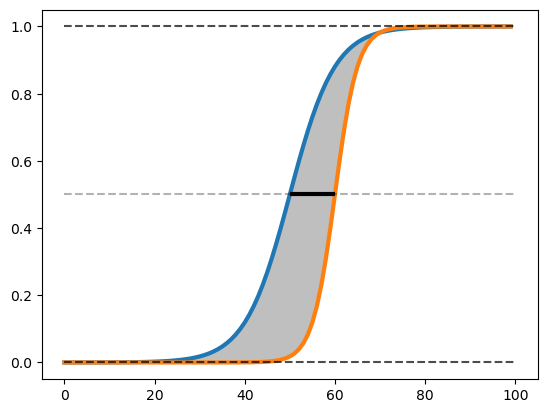

In [ ]:
x= np.arange(100)
y1 = pmd.sigmoid(x, 50, 0.2)
y2 = pmd.sigmoid(x, 60, 0.4)

plt.plot(x, y1, linewidth=3)
plt.plot(x, y2, linewidth=3)
plt.hlines(0, 0, 100, colors='black', linestyles='--', alpha=0.7)
plt.hlines(1, 0, 100, colors='black', linestyles='--', alpha=0.7)
plt.hlines(0.5, 0, 100, colors='black', linestyles='--', alpha=0.3)
plt.hlines(0.5, 50, 60, colors='k', linewidth=3)
plt.fill_between(x, y1, y2, color='gray', alpha=0.5)
np.abs(y1 - y2).sum()